In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Real_Estate.csv")

display(df.head(5))

,Transaction date,House age,Distance to the nearest MRT station,Number of convenience stores,Latitude,Longitude,House price of unit area
0,2012-09-02 16:42:30.519336,13.3,4082.0150,8,25.007059,121.561694,6.488673
1,2012-09-04 22:52:29.919544,35.5,274.0144,2,25.012148,121.546990,24.970725
2,2012-09-05 01:10:52.349449,1.1,1978.6710,10,25.003850,121.528336,26.694267
3,2012-09-05 13:26:01.189083,22.2,1055.0670,5,24.962887,121.482178,38.091638
4,2012-09-06 08:29:47.910523,8.5,967.4000,6,25.011037,121.479946,21.654710


In [18]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Transaction date                     414 non-null    object 
 1   House age                            414 non-null    float64
 2   Distance to the nearest MRT station  414 non-null    float64
 3   Number of convenience stores         414 non-null    int64  
 4   Latitude                             414 non-null    float64
 5   Longitude                            414 non-null    float64
 6   House price of unit area             414 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 22.8+ KB
None


In [23]:
print("\nКоличество дубликатов (полных):", df.duplicated().sum())

print("\nКоличество нулевых цен:", df[df["House price of unit area"] == 0]["House price of unit area"].count())
new_df = df[df["House price of unit area"] != 0]
print("\nКоличество нулевых цен после удаления:", new_df[new_df["House price of unit area"] == 0]["House price of unit area"].count())

new_df.to_csv("estate_data_ready.csv")


Количество дубликатов (полных): 0

Количество нулевых цен: 31

Количество нулевых цен после удаления: 0


In [20]:
display(new_df.describe())

,House age,Distance to the nearest MRT station,Number of convenience stores,Latitude,Longitude,House price of unit area
count,383.000000,383.000000,383.000000,383.000000,383.000000,383.000000
mean,18.495300,852.783999,4.357702,24.973403,121.519887,31.457675
std,11.805903,919.225405,2.859720,0.023994,0.026669,13.925937
min,0.000000,23.382840,0.000000,24.932075,121.473888,0.365176
25%,9.800000,283.387550,2.000000,24.952410,121.497312,21.683307
50%,16.500000,482.758100,5.000000,24.974157,121.520479,32.154001
75%,30.400000,1200.701000,7.000000,24.994594,121.543776,41.405477
max,42.700000,5512.038000,10.000000,25.014578,121.565321,65.571716


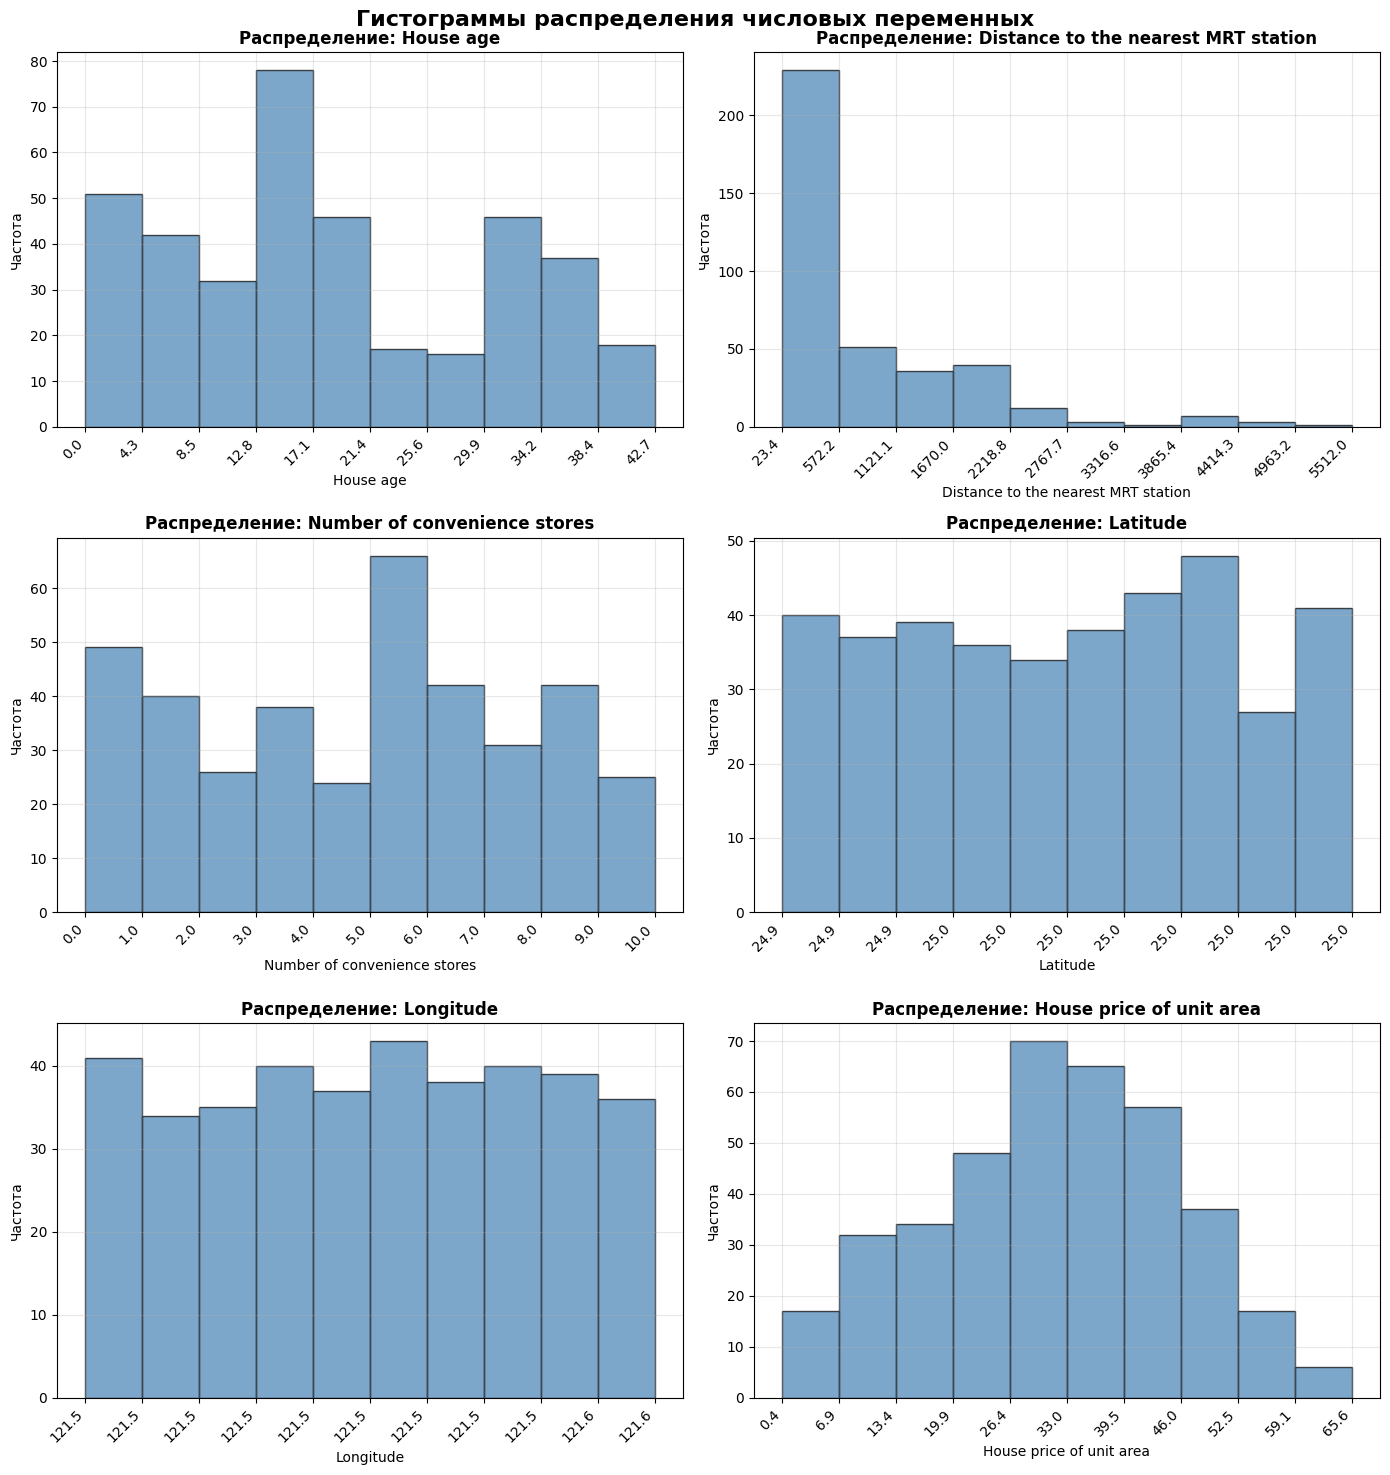

In [21]:
numeric_columns = new_df.select_dtypes(include=[np.number]).columns.tolist()

def sturges_rule(data):
    n = len(data.dropna())
    return int(np.ceil(np.log2(n) + 1))

# Настройка размера графиков
n_cols = 2
n_rows = (len(numeric_columns) + n_cols - 1) // n_cols
# Создание фигуры с подграфиками
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if len(numeric_columns) > 1 else [axes]

# Построение гистограмм для каждого числового столбца
for idx, col in enumerate(numeric_columns):
    # Вычисляем количество интервалов по формуле Стерджесса
    n_bins = sturges_rule(new_df[col])

    # Создаем границы интервалов от мин до макс значения
    min_val = new_df[col].min()
    max_val = new_df[col].max()
    bins = np.linspace(min_val, max_val, n_bins + 1)
    axes[idx].set_xticks(bins)
    axes[idx].set_xticklabels([f'{x:.1f}' for x in bins], rotation=45, ha='right')
    
    axes[idx].hist(new_df[col], bins=n_bins, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'Распределение: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Частота', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

for idx in range(len(numeric_columns), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Гистограммы распределения числовых переменных', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()